##### Author: Jimin Kim (jk55@uw.edu)
##### Version 1.7.0

# Lab 2 Report

### Group Members:

In [3]:
import numpy as np

# Exercise 1: Loops vs Numpy operations

<img src="lab2_exercise1.png" width="1000">

In [4]:
import time # Import time to measure computational efficiency of the code

In [5]:
arr2d_1 = np.random.randn(1000, 1000) * 10
arr2d_2 = np.random.randn(1000, 1000) * 10

In [6]:
# Elementwise addition using loop

arr2d_3_loop = np.zeros((1000, 1000)) # Create a placeholder array for arr2d_3

start_time_loop = time.time() # start time of the code

# YOUR CODE HERE FOR ELEMENTWISE ADDITION USING TWO NESTED LOOPS
for i in range(1000):
    for j in range(1000):
        arr2d_3_loop[i][j] = arr2d_1[i][j]  + arr2d_2[i][j]

end_time_loop = time.time() # end time of the code

elapsed_time_loop = end_time_loop - start_time_loop # end time - start time -> elapsed time in seconds
print(elapsed_time_loop)

0.5169789791107178


In [7]:
# Elementwise addition using Numpy function

start_time_np = time.time()

arr2d_3_np = np.add(arr2d_1, arr2d_2)  # YOUR CODE HERE

end_time_np = time.time()

elapsed_time_np = end_time_np - start_time_np
print(elapsed_time_np)

0.0012102127075195312


In [8]:
# Make sure two outputs are equivalent

np.sum(arr2d_3_loop == arr2d_3_np) == 1000 * 1000 # Should output True if the outputs are same

True

### Which computation is faster and by what factor?
### e.g. a code that takes 0.1s is faster by a factor of 10 compared to a code that takes 1s

In [9]:
# Numpy's inbuilt method is much faster, by a factor of about 1000

# Exercise 2: Generate Triangular Waveform

<img src="lab2_exercise2.png" width="1000">

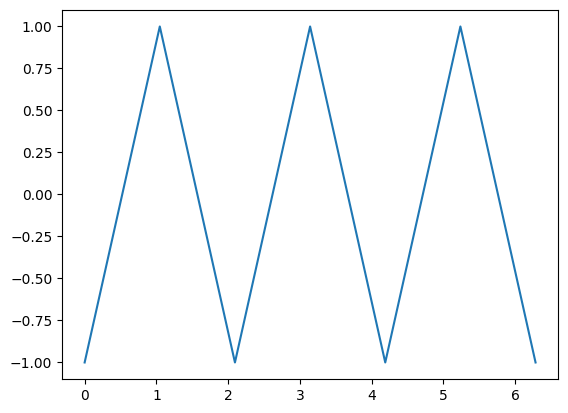

In [24]:
# Your code here
#%matplotlab inline
import matplotlib.pyplot as plt
x = np.arange(0,6.5,(2 * np.pi)/12)
y = -np.cos(3*x)
plt.plot(x, y)

# Exercise 3: Sinusoidal Generator

<img src="lab2_exercise3.png" width="1000">

In [80]:
# Define generate_sine function

def generate_sine(t_duration, f0, fs):
    t_arr = np.arange(0, t_duration, 1/fs)
    amplitudes = np.sin(np.array(t_arr) * 2 * np.pi * f0)
    # Return 1D numpy arrays each containing timepoints and sine waveform amplitudes
    return t_arr, amplitudes 

In [36]:
# parameter set 1
t_duration_1 = 5
f0_1 = 0.5
fs_1 = 100
t_arr_1, amplitudes_1 = generate_sine(t_duration_1, f0_1, fs_1)

# parameter set 2
t_duration_2 = 5
f0_2 = 1.
fs_2 = 100
t_arr_2, amplitudes_2 = generate_sine(t_duration_2, f0_2, fs_2)

# parameter set 3
t_duration_3 = 5
f0_3 = 1.5
fs_3 = 100
t_arr_3, amplitudes_3 = generate_sine(t_duration_3, f0_3, fs_3)

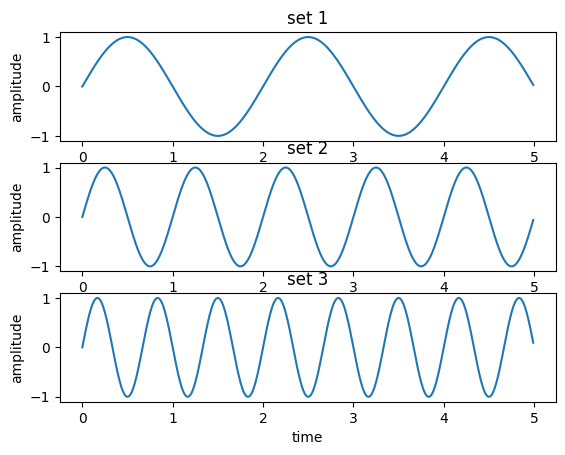

In [38]:
# Plot 3 x 1 subplot showing all three waveform
plt.subplot(311)
plt.title("set 1")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.plot(t_arr_1,amplitudes_1)

plt.subplot(312)
plt.title("set 2")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.plot(t_arr_2,amplitudes_2)

plt.subplot(313)
plt.title("set 3")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.plot(t_arr_3,amplitudes_3)

# Exercise 4: Notes Synthesis

<img src="lab2_exercise4.png" width="1000">

In [66]:
# YOUR CODE HERE
from scipy.io import wavfile as wav
import IPython
t1, a1 = generate_sine(1, 220, 8000)
t2, a2 = generate_sine(1, 220 * 2**(2/12), 8000)
t3, a3 = generate_sine(1, 220 * 2**(4/12), 8000)
t4, a4 = generate_sine(1, 220 * 2**(5/12), 8000)
t5, a5 = generate_sine(1, 220 * 2**(7/12), 8000)
t6, a6 = generate_sine(1, 220 * 2**(9/12), 8000)
t7, a7 = generate_sine(1, 220 * 2**(11/12), 8000)
t8, a8 = generate_sine(1, 440, 8000)
data = np.concatenate([a1, a2, a3, a4, a5, a6, a7, a8]) * 32767

outfile = 'a_major_scale.wav'
wav.write(outfile, 8000, data.astype('int16'))
IPython.display.Audio(outfile)

In [61]:
# NOTE: Multiply your concatenated notes (with amplitude of 1) with 32767 followed by conversion to int16 format
# before playing or writing your audio array into a file. 

# Exercise 5: Chord Synthesis

<img src="lab2_exercise5.png" width="1000">

In [96]:
# YOUR CODE HERE
t1, a1 = generate_sine(1, 220, 8000)
t2, a2 = generate_sine(1, 220 * 2**(2/12), 8000)
t3, a3 = generate_sine(1, 220 * 2**(4/12), 8000)
t4, a4 = generate_sine(1, 220 * 2**(5/12), 8000)
t5, a5 = generate_sine(1, 220 * 2**(7/12), 8000)
t6, a6 = generate_sine(1, 220 * 2**(9/12), 8000)
t7, a7 = generate_sine(1, 220 * 2**(11/12), 8000)
t8, a8 = generate_sine(1, 440, 8000)

data = np.concatenate([a1 + a3, a2 + a4, a3 + a5, a4 + a6, a5 + a7, a6 + a8])
data = (2 * ((data-np.min(data))/(np.max(data)-np.min(data))) - 1) * 32767
outfile = '6_chords.wav'
wav.write(outfile, 8000, data.astype('int16'))
IPython.display.Audio(outfile)

In [ ]:
# NOTE: Multiply your concatenated notes (with amplitude of 1) with 32767 followed by conversion to int16 format
# before playing or writing your audio array into a file. 